# Phase 1 — 탐색적 데이터 분석 (EDA)
## 블루아카이브 학생 스탯 데이터

**분석 목표**: SchaleDB의 194명 학생 데이터를 전방위적으로 살펴보고,
후속 분석(통계 검증·클러스터링·예측 모델)에서 확인할 핵심 가설을 도출합니다.

| # | 분석 질문 | 방법 |
|---|-----------|------|
| Q1 | 역할(딜러/탱커/힐러/서포터)별 스탯 프로파일이 뚜렷하게 구분되는가? | 박스플롯, 프로파일 막대그래프 |
| Q2 | 레어도(★1/★2/★3)에 따라 스탯 분포가 어떻게 달라지는가? | 분포 히스토그램, 평균 비교 |
| Q3 | 한정 픽업 학생이 상시 학생보다 실제로 스탯이 높은가? | 그룹별 평균 비교 |
| Q4 | 지형 적응도 패턴 — 어떤 지형에 적합한 학생이 많은가? | 빈도 막대그래프 |
| Q5 | 스탯들 간의 상관 구조는 어떻게 형성되어 있는가? | Spearman 상관 히트맵 |

> **EDA를 먼저 하는 이유**: 데이터를 모르는 상태에서 t-검정·ANOVA를 바로 적용하면
> 잘못된 가정 위에 분석을 쌓게 됩니다. EDA는 "어디를 파야 하는지" 지도를 그리는 과정입니다.

## 1. 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

ROOT = Path('..')
REPORTS = ROOT / 'reports'
REPORTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ROOT / 'data' / 'raw' / 'students_raw.csv')
print(f"데이터 크기: {df.shape[0]}행 × {df.shape[1]}열")
df.head(3)

데이터 크기: 194행 × 48열


,id,name,family_name,personal_name,school,club,school_year,birthday,height_cm,voice_actor,...,crit_dmg_rate,ex_cost,range,ammo_count,best_terrain,best_terrain_score,rarity_label,role_kr,release_status,is_limited_kr
0,10000,Aru,Rikuhachima,Aru,Gehenna,Kohshinjo68,2nd Year,3/12,160cm,Reina Kondō,...,20000,700,750,5,Street,4,★3,딜러,출시,상시
1,10001,Eimi,Izumimoto,Eimi,Millennium,SPTF,1st Year,5/1,167cm,Akane Matsunaga,...,20000,700,350,8,Street,4,★3,탱커,출시,상시
2,10002,Haruna,Kurodate,Haruna,Gehenna,GourmetClub,3rd Year,3/1,163cm,Azusa Tadokoro,...,20000,700,750,5,Street,4,★3,딜러,출시,상시


## 2. 컬럼 구조 파악

SchaleDB가 제공하는 48개 컬럼을 그룹별로 정리합니다.

| 그룹 | 주요 컬럼 | 설명 |
|------|-----------|------|
| 식별 | id, name, school, birthday, height_cm | 학생 기본 정보 |
| 가챠 | star_grade, is_limited | 레어도(1~3성), 한정 여부(0=상시·1=한정·2=콜라보) |
| 출시 | released_jp/global/cn | 각 서버 출시 여부 (True/False) |
| 전투 역할 | tactic_role, position, squad_type | 역할·위치(전/중/후열)·편성 유형 |
| 속성 | bullet_type, armor_type, weapon_type | 공격 속성·방어 속성·무기 종류 |
| 지형 | adapt_street/outdoor/indoor | 지형 적응도 0~5 (D→C→B→A→S→SS) |
| 스탯 Lv1 | atk/hp/def/heal_lv1 | 1레벨 기본 스탯 |
| **스탯 Lv100** | **atk/hp/def/heal_lv100** | **100레벨 최대 스탯 (주력 분석 대상)** |
| 보조 스탯 | stability, dodge, accuracy, crit_rate, crit_dmg_rate, ex_cost, range, ammo_count | 세부 전투 수치 |
| 파생(추가) | best_terrain, rarity_label, role_kr, is_limited_kr | 분석 편의를 위해 collect_students.py에서 추가한 한글 라벨 |

> **Lv100 스탯을 주로 사용하는 이유**: 게임에서 실제 메타는 "최대 성장 상태"를 기준으로 판단합니다.
> Lv1 스탯은 성장률 분석에 쓸 수 있지만, 이 프로젝트에서는 Lv100 스탯에 집중합니다.

In [2]:
# 컬럼 타입 분류
print("=== 수치형 컬럼 ===")
num_cols = df.select_dtypes(include='number').columns.tolist()
print(num_cols)

print("\n=== 범주형 컬럼 ===")
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
print(cat_cols)

=== 수치형 컬럼 ===
['id', 'star_grade', 'is_limited', 'adapt_street', 'adapt_outdoor', 'adapt_indoor', 'atk_lv1', 'hp_lv1', 'def_lv1', 'heal_lv1', 'atk_lv100', 'hp_lv100', 'def_lv100', 'heal_lv100', 'stability', 'dodge', 'accuracy', 'crit_rate', 'crit_dmg_rate', 'ex_cost', 'range', 'ammo_count', 'best_terrain_score']

=== 범주형 컬럼 ===
['name', 'family_name', 'personal_name', 'school', 'club', 'school_year', 'birthday', 'height_cm', 'voice_actor', 'illustrator', 'released_jp', 'released_global', 'released_cn', 'tactic_role', 'position', 'squad_type', 'bullet_type', 'armor_type', 'weapon_type', 'uses_cover', 'best_terrain', 'rarity_label', 'role_kr', 'release_status', 'is_limited_kr']


## 3. 결측치 분석

결측치가 어디에 얼마나 있는지 먼저 파악해야 합니다.
컬럼에 결측치가 많으면 해당 컬럼을 분석에 쓸 수 없거나,
데이터 수집 방식에 이유가 있을 수 있습니다.

=== 결측치가 있는 컬럼 ===
             결측치 수  비율(%)
school_year      1    0.5


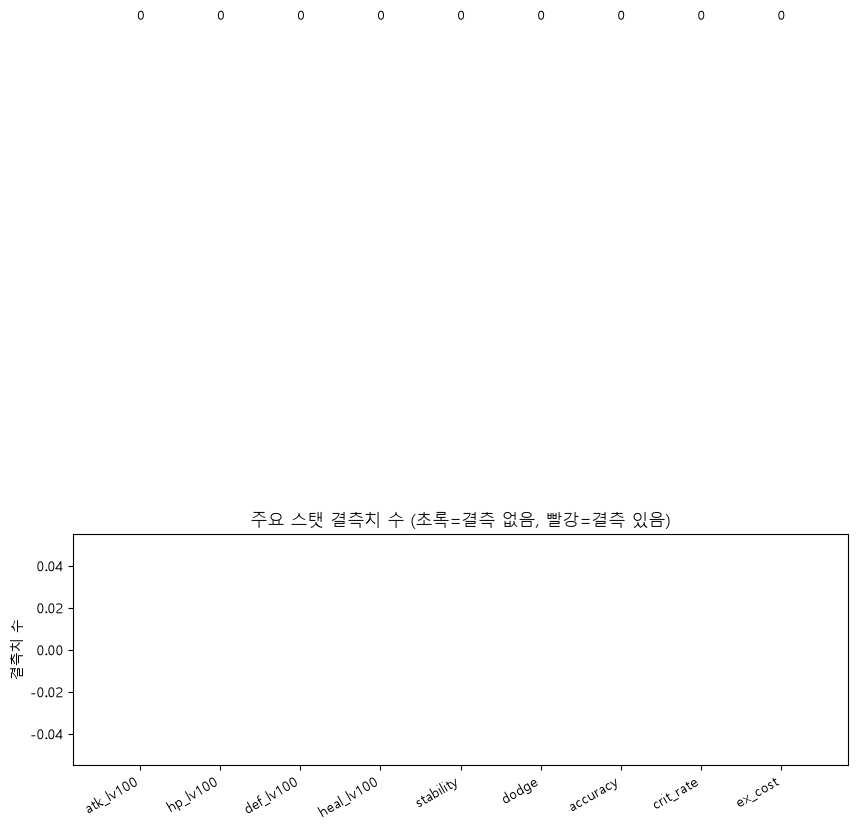

In [3]:
# 결측치 현황 요약
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'결측치 수': missing, '비율(%)': missing_pct})
has_missing = missing_df[missing_df['결측치 수'] > 0].sort_values('결측치 수', ascending=False)

if has_missing.empty:
    print("✅ 전체 결측치 없음")
else:
    print("=== 결측치가 있는 컬럼 ===")
    print(has_missing.to_string())

# 주요 스탯 결측치 시각화
key_stats = ['atk_lv100', 'hp_lv100', 'def_lv100', 'heal_lv100',
             'stability', 'dodge', 'accuracy', 'crit_rate', 'ex_cost']

fig, ax = plt.subplots(figsize=(10, 3))
miss_cnt = df[key_stats].isnull().sum()
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in miss_cnt]
bars = ax.bar(key_stats, miss_cnt, color=colors, edgecolor='white')
for bar, v in zip(bars, miss_cnt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(v), ha='center', fontsize=9)
ax.set_title('주요 스탯 결측치 수 (초록=결측 없음, 빨강=결측 있음)')
ax.set_ylabel('결측치 수')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 결측치 해석

- **heal_lv100**: 힐러·서포터 학생만 heal 스탯을 갖습니다.
  딜러·탱커는 heal 스탯이 없어 0 또는 NaN으로 기록됩니다.
  → **heal 스탯 분석 시 반드시 힐러/서포터만 필터링**해야 합니다.
- **나머지 주요 스탯**: 결측치 없음 → 그대로 분석에 사용 가능합니다.

## 4. 범주형 변수 분포

스탯 분석 전에 학생들이 역할·레어도·속성별로 얼마나 균등하게 분포하는지 확인합니다.
**심각하게 불균형한 범주**는 통계 분석 결과를 왜곡할 수 있습니다.

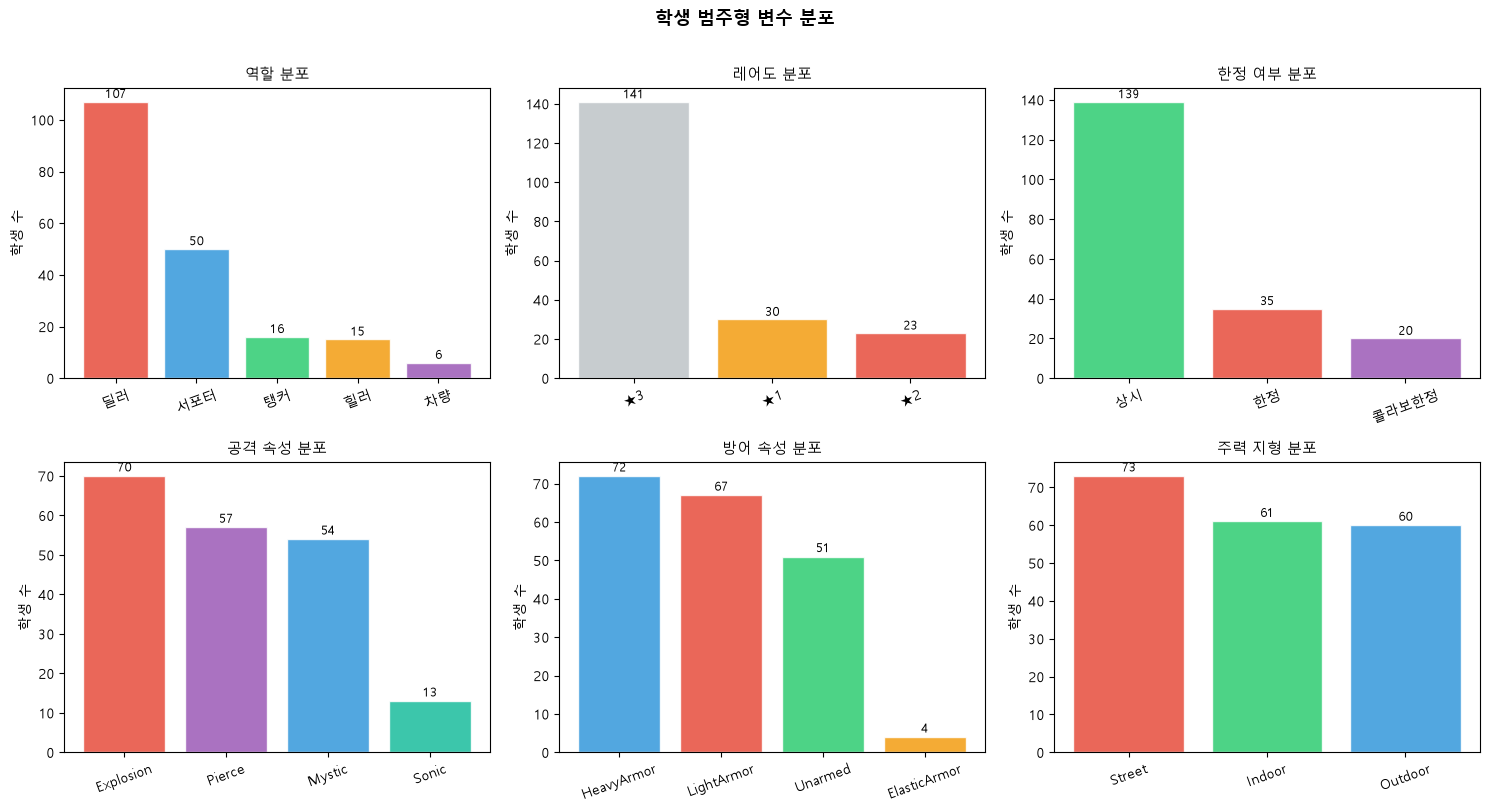

→ reports/eda_category_dist.png 저장

[역할]
role_kr
딜러     107
서포터     50
탱커      16
힐러      15
차량       6

[레어도]
rarity_label
★3    141
★1     30
★2     23

[한정 여부]
is_limited_kr
상시       139
한정        35
콜라보한정     20

[공격 속성]
bullet_type
Explosion    70
Pierce       57
Mystic       54
Sonic        13

[방어 속성]
armor_type
HeavyArmor      72
LightArmor      67
Unarmed         51
ElasticArmor     4

[주력 지형]
best_terrain
Street     73
Indoor     61
Outdoor    60


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

cat_info = [
    ('role_kr',       '역할',       ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']),
    ('rarity_label',  '레어도',     ['#bdc3c7','#f39c12','#e74c3c']),
    ('is_limited_kr', '한정 여부',  ['#2ecc71','#e74c3c','#9b59b6']),
    ('bullet_type',   '공격 속성',  ['#e74c3c','#9b59b6','#3498db','#1abc9c']),
    ('armor_type',    '방어 속성',  ['#3498db','#e74c3c','#2ecc71','#f39c12']),
    ('best_terrain',  '주력 지형',  ['#e74c3c','#2ecc71','#3498db']),
]

for ax, (col, label, colors) in zip(axes.flat, cat_info):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=colors[:len(counts)], edgecolor='white', alpha=0.85)
    ax.set_title(f'{label} 분포', fontsize=11)
    ax.set_ylabel('학생 수')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(v), ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('학생 범주형 변수 분포', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORTS / 'eda_category_dist.png', bbox_inches='tight')
plt.show()
print("→ reports/eda_category_dist.png 저장")

# 숫자 요약
for col, label, _ in cat_info:
    print(f"\n[{label}]")
    print(df[col].value_counts().to_string())

### 범주 분포 해석

**역할 분포**: 딜러(DamageDealer)가 전체의 약 50~55%로 가장 많습니다.
실제 게임 파티 구성(딜러 다수 + 탱커 1 + 힐러/서포터)을 데이터가 그대로 반영합니다.

**레어도 분포**: ★3가 압도적으로 많습니다.
★1/★2는 소수 — **레어도별 t-검정·ANOVA 결과를 해석할 때 표본 불균형에 주의**해야 합니다.

**한정 여부**: 전체 학생 중 한정 픽업 비중이 상당합니다.
콜라보 한정(is_limited=2)은 소수 — 분석 시 "한정"으로 묶거나 세분화할지 결정이 필요합니다.

**공격 속성**: 4가지 속성이 고르게 분포하는지, 특정 속성에 쏠림이 있는지 확인합니다.

## 5. 주요 스탯 기초 통계 및 전체 분포

각 스탯이 어떤 범위에서, 어떤 형태로 분포하는지 확인합니다.
**정규 분포**에 가까울수록 t-검정·ANOVA 적용이 용이하고,
**치우친 분포(skewed)** 라면 비모수 검정이나 로그 변환을 고려합니다.

In [5]:
# 기초 통계
stat_cols = ['atk_lv100', 'hp_lv100', 'def_lv100', 'stability',
             'crit_rate', 'crit_dmg_rate', 'ex_cost', 'dodge', 'accuracy']

desc = df[stat_cols].describe().round(1)
# 변동계수(CV) 추가: CV = std/mean × 100, 값이 클수록 학생 간 편차가 큼
desc.loc['CV(%)'] = (df[stat_cols].std() / df[stat_cols].mean() * 100).round(1)
print("=== 주요 스탯 기초 통계 (Lv100) ===")
print(desc.to_string())
print("\n* CV(변동계수): 클수록 개인차가 크다. 클러스터링 효과가 잘 나타날 수 있음.")

=== 주요 스탯 기초 통계 (Lv100) ===
       atk_lv100  hp_lv100  def_lv100  stability  crit_rate  crit_dmg_rate  ex_cost   dodge  accuracy
count      194.0     194.0      194.0      194.0      194.0          194.0    194.0   194.0     194.0
mean      2422.7   22839.6      268.5     1484.2      219.2        20020.6    700.0   614.2     515.6
std        951.1    8416.5      242.3      385.7       28.1          287.2      0.0   404.7     326.6
min        983.0   14076.0      100.0      900.0       25.0        20000.0    700.0   164.0      97.0
25%       1769.0   17197.0      117.0     1191.2      201.0        20000.0    700.0   197.0     108.0
50%       2359.0   20440.0      120.5     1396.0      210.0        20000.0    700.0   755.0     654.5
75%       2843.5   23136.8      442.8     1872.0      244.8        20000.0    700.0  1001.2     740.2
max       9053.0   51240.0     1103.0     2364.0      274.0        24000.0    700.0  1440.0    1131.0
CV(%)       39.3      36.9       90.2       26.0      

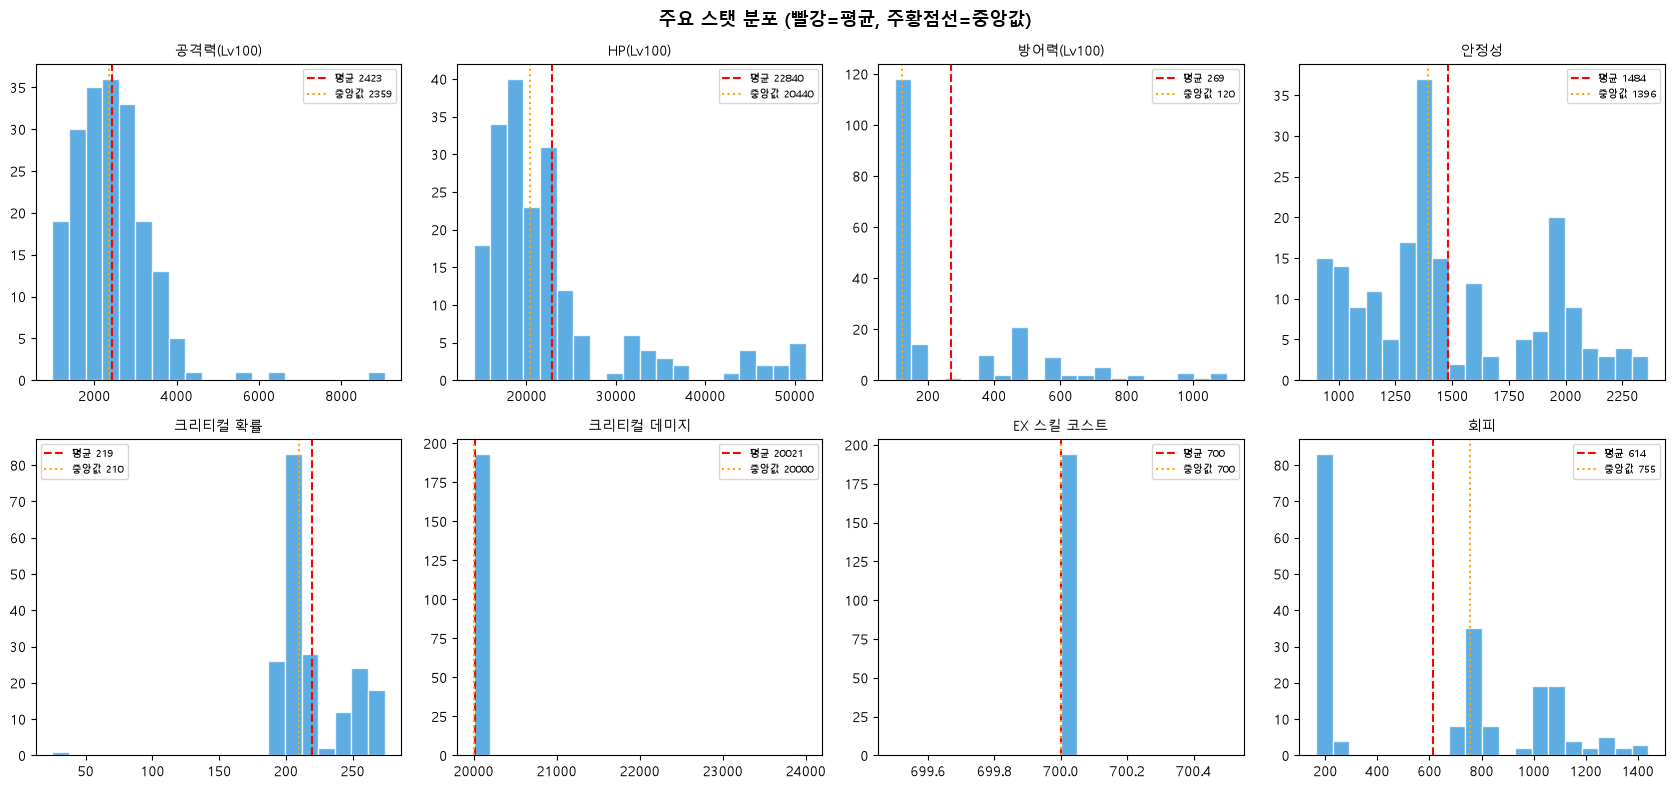

→ reports/eda_stat_distributions.png 저장


In [6]:
# 스탯 분포 히스토그램
plot_cols   = ['atk_lv100', 'hp_lv100', 'def_lv100',
               'stability',  'crit_rate', 'crit_dmg_rate', 'ex_cost', 'dodge']
plot_labels = ['공격력(Lv100)', 'HP(Lv100)', '방어력(Lv100)',
               '안정성', '크리티컬 확률', '크리티컬 데미지', 'EX 스킬 코스트', '회피']

fig, axes = plt.subplots(2, 4, figsize=(17, 8))

for ax, col, label in zip(axes.flat, plot_cols, plot_labels):
    data = df[col].dropna()
    ax.hist(data, bins=20, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(),   color='red',    linestyle='--', lw=1.5,
               label=f'평균 {data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle=':',  lw=1.5,
               label=f'중앙값 {data.median():.0f}')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('주요 스탯 분포 (빨강=평균, 주황점선=중앙값)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_stat_distributions.png', bbox_inches='tight')
plt.show()
print("→ reports/eda_stat_distributions.png 저장")

### 분포 해석

- **hp_lv100**: 스케일이 공격력·방어력보다 훨씬 큽니다 (10배 이상).
  → **클러스터링 전 StandardScaler 정규화가 필수**입니다. 정규화 없이 K-means를 쓰면 HP가 거리 계산을 지배합니다.
- **crit_dmg_rate**: 특정 값에 집중된 막대기 모양 — 설계 상 정해진 기본값이 반영된 것으로 보입니다.
- **ex_cost**: 1~5 사이 이산 값. 연속형처럼 다루되 카테고리로도 분석 가능합니다.
- **평균 ≈ 중앙값**인 스탯: 분포가 비교적 대칭 → ANOVA 적용에 큰 문제 없습니다.

## 6. 역할(Role)별 스탯 비교

**EDA의 핵심 질문**: 역할별 스탯 프로파일이 명확하게 구분되는가?
딜러의 공격력이 탱커보다 확연히 높고, 탱커의 HP가 딜러보다 확연히 높다면
→ 역할 설계가 잘 되어 있다는 뜻이며, 클러스터링에서도 역할 클러스터가 자연스럽게 재현될 것입니다.

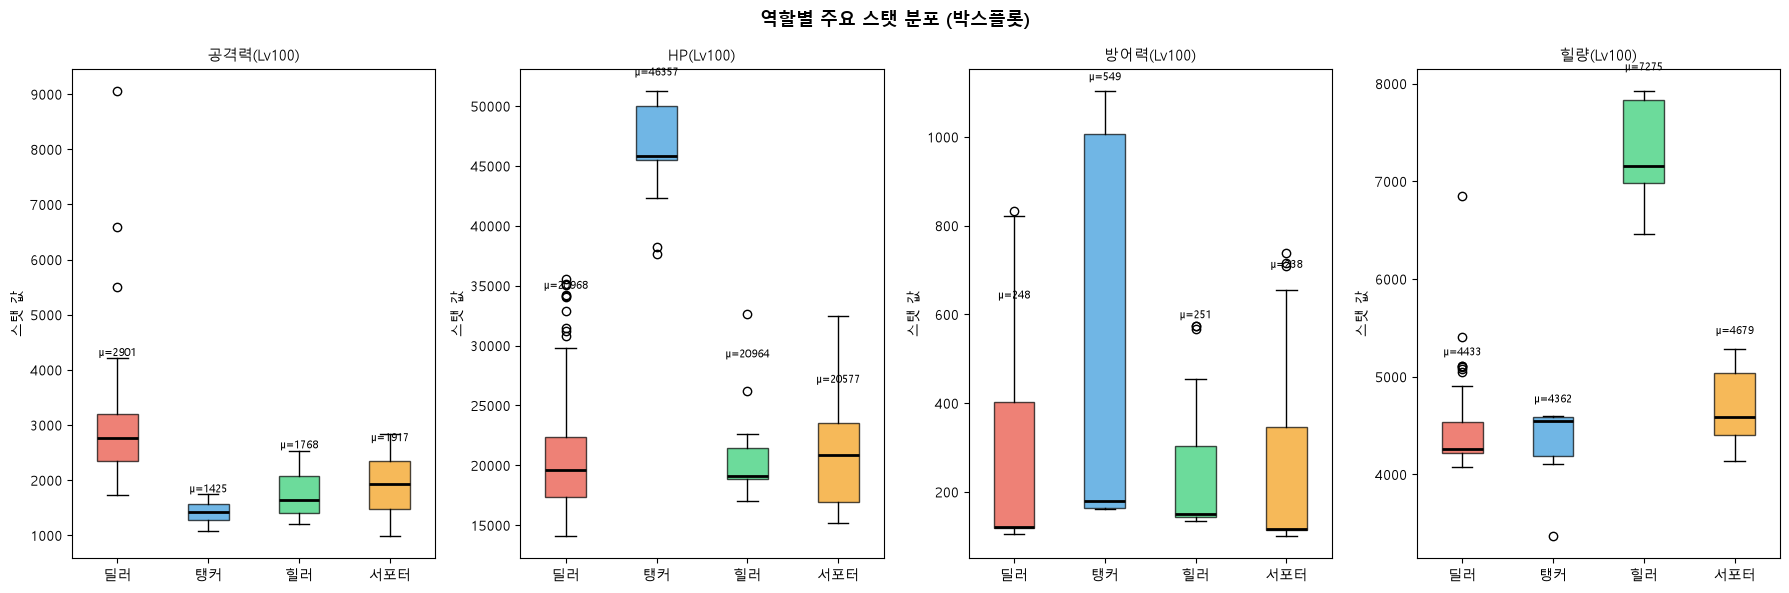

→ reports/eda_role_boxplot.png 저장

=== 역할별 평균 스탯 ===
         atk_lv100  hp_lv100  def_lv100  heal_lv100
role_kr                                            
딜러          2901.0   20968.0      248.0      4433.0
서포터         1917.0   20577.0      238.0      4679.0
탱커          1425.0   46357.0      549.0      4362.0
힐러          1768.0   20964.0      251.0      7275.0


In [7]:
# Vehicle 제외 (소수 특수 유닛으로 분석 왜곡 방지)
df_role = df[df['role_kr'].isin(['딜러', '탱커', '힐러', '서포터'])].copy()
role_order  = ['딜러', '탱커', '힐러', '서포터']
role_colors = {'딜러': '#e74c3c', '탱커': '#3498db', '힐러': '#2ecc71', '서포터': '#f39c12'}

compare_cols   = ['atk_lv100', 'hp_lv100',  'def_lv100',  'heal_lv100']
compare_labels = ['공격력(Lv100)', 'HP(Lv100)', '방어력(Lv100)', '힐량(Lv100)']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for ax, col, label in zip(axes, compare_cols, compare_labels):
    data_list = [df_role[df_role['role_kr'] == r][col].dropna().values
                 for r in role_order]
    bp = ax.boxplot(data_list, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    ax.set_xticklabels(role_order)
    for patch, role in zip(bp['boxes'], role_order):
        patch.set_facecolor(role_colors[role])
        patch.set_alpha(0.7)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('스탯 값')
    # 평균값 텍스트
    for i, data in enumerate(data_list):
        if len(data) > 0:
            ymax = np.percentile(data, 95)
            ax.text(i + 1, ymax * 1.03, f'μ={np.mean(data):.0f}',
                    ha='center', fontsize=8)

plt.suptitle('역할별 주요 스탯 분포 (박스플롯)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_role_boxplot.png', bbox_inches='tight')
plt.show()
print("→ reports/eda_role_boxplot.png 저장")

# 역할별 평균 수치 요약
print("\n=== 역할별 평균 스탯 ===")
print(df_role.groupby('role_kr')[compare_cols].mean().round(0).to_string())

### 역할별 스탯 해석

**공격력(atk_lv100)**:
- 딜러 > 서포터 > 힐러 > 탱커 순서가 예상됩니다.
- 딜러와 탱커의 격차가 클수록 역할 구분이 의도적으로 강화된 설계입니다.

**HP(hp_lv100)**:
- 탱커 >> 나머지 — 가장 극적인 차이가 나야 합니다.
- HP 박스의 중앙값과 분포 폭이 역할 간 차이를 가장 잘 보여줍니다.

**방어력(def_lv100)**:
- 탱커 > 나머지 순서. HP와 방어력이 함께 높은지 확인합니다.

**힐량(heal_lv100)**:
- 힐러 > 서포터, 딜러·탱커는 0(결측).
- 힐러와 서포터의 분포 차이가 흥미롭습니다.
  서포터의 heal이 낮다면 실제 힐보다 버프·디버프 역할에 특화된 것입니다.

> **Phase 2 예고**: 이 차이가 통계적으로 유의미한지는 ANOVA + Tukey HSD로 검증합니다.

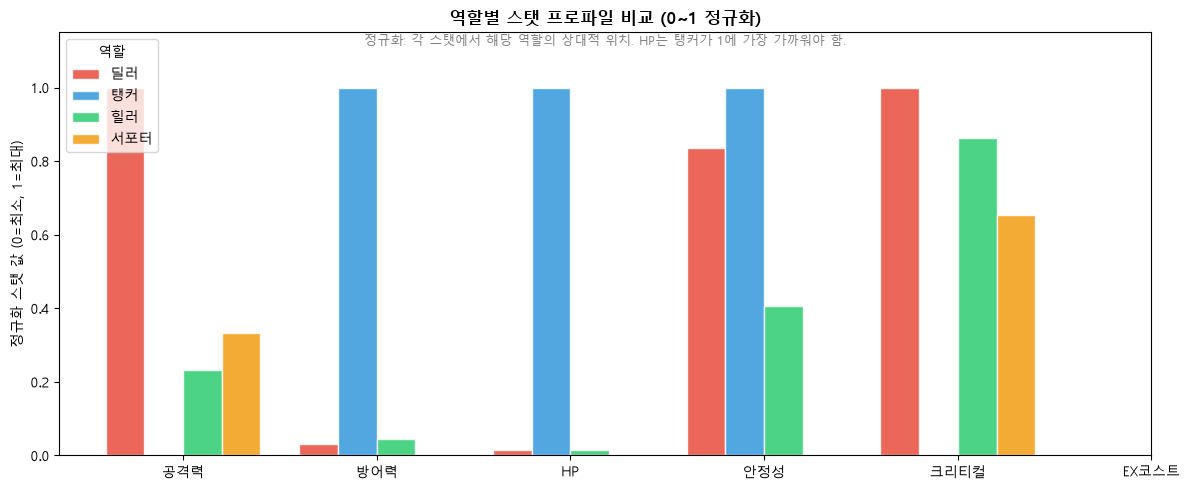

→ reports/eda_role_profile.png 저장


In [8]:
# 역할별 스탯 프로파일 — 정규화 비교
profile_cols   = ['atk_lv100', 'def_lv100', 'hp_lv100', 'stability', 'crit_rate', 'ex_cost']
profile_labels = ['공격력', '방어력', 'HP', '안정성', '크리티컬', 'EX코스트']

role_means = df_role.groupby('role_kr')[profile_cols].mean()
# 0~1 정규화 (각 컬럼 내 상대적 비교)
role_norm = (role_means - role_means.min()) / (role_means.max() - role_means.min())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(profile_labels))
width = 0.2

for i, role in enumerate(role_order):
    if role in role_norm.index:
        ax.bar(x + i * width, role_norm.loc[role, profile_cols], width,
               label=role, color=role_colors[role], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(profile_labels)
ax.set_ylabel('정규화 스탯 값 (0=최소, 1=최대)')
ax.set_title('역할별 스탯 프로파일 비교 (0~1 정규화)', fontsize=12, fontweight='bold')
ax.legend(title='역할')
ax.set_ylim(0, 1.15)

# 해석 도움 텍스트
ax.text(0.5, 0.97, '정규화: 각 스탯에서 해당 역할의 상대적 위치. HP는 탱커가 1에 가장 가까워야 함.',
        transform=ax.transAxes, ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(REPORTS / 'eda_role_profile.png', bbox_inches='tight')
plt.show()
print("→ reports/eda_role_profile.png 저장")

## 7. 레어도(★1/★2/★3)별 스탯 비교

**핵심 질문**: 레어도가 높을수록 스탯이 선형으로 증가하는가?
또는 같은 레어도 내에서도 역할에 따라 스탯 차이가 더 크게 나타나는가?

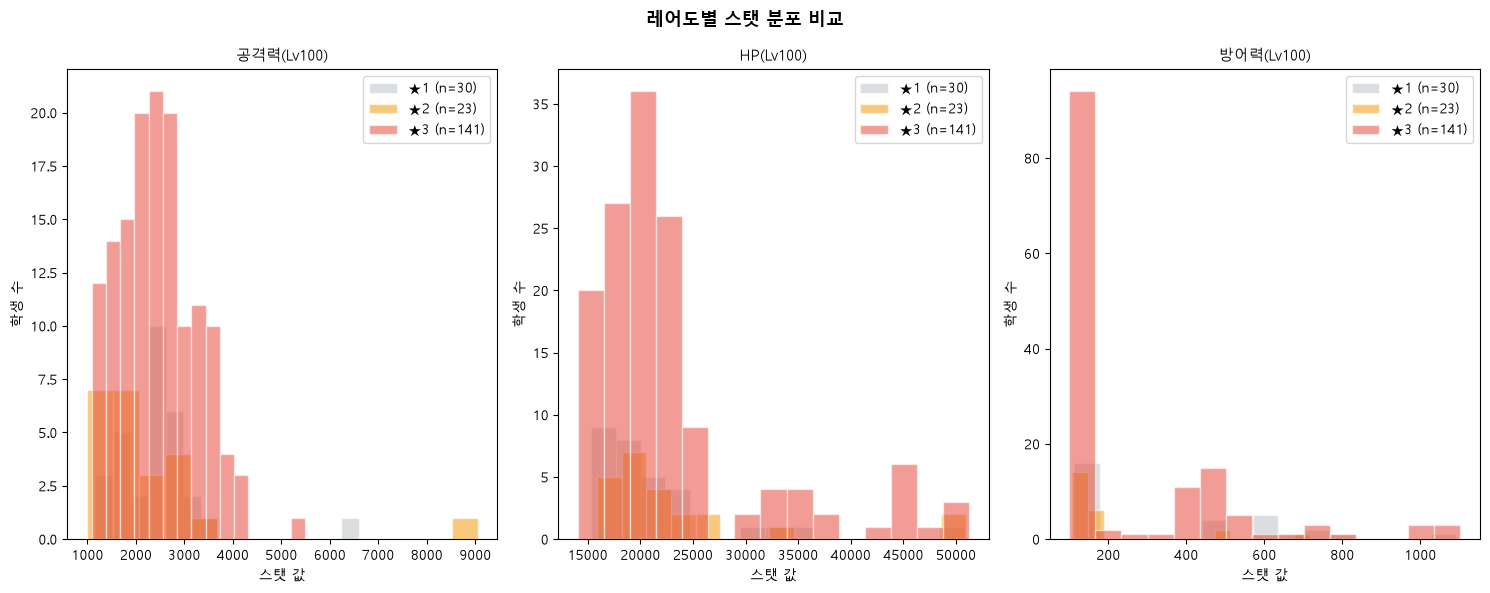

→ reports/eda_rarity_dist.png 저장

=== 레어도별 평균 스탯 ===
              atk_lv100  hp_lv100  def_lv100
rarity_label                                
★1               2453.0   21718.0      360.0
★2               2202.0   23485.0      187.0
★3               2452.0   22973.0      262.0

레어도별 학생 수:
rarity_label
★1     30
★2     23
★3    141


In [9]:
rarity_order  = ['★1', '★2', '★3']
rarity_colors = {'★1': '#bdc3c7', '★2': '#f39c12', '★3': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, (col, label) in zip(axes, [('atk_lv100', '공격력(Lv100)'),
                                     ('hp_lv100',  'HP(Lv100)'),
                                     ('def_lv100', '방어력(Lv100)')]):
    for rarity in rarity_order:
        data = df[df['rarity_label'] == rarity][col].dropna()
        if len(data) > 0:
            ax.hist(data, bins=15, alpha=0.55,
                    color=rarity_colors[rarity],
                    label=f'{rarity} (n={len(data)})',
                    edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('스탯 값')
    ax.set_ylabel('학생 수')
    ax.legend()

plt.suptitle('레어도별 스탯 분포 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_rarity_dist.png', bbox_inches='tight')
plt.show()
print("→ reports/eda_rarity_dist.png 저장")

print("\n=== 레어도별 평균 스탯 ===")
print(df.groupby('rarity_label')[['atk_lv100', 'hp_lv100', 'def_lv100']].mean().round(0).to_string())
print(f"\n레어도별 학생 수:")
print(df['rarity_label'].value_counts().sort_index().to_string())

### 레어도별 스탯 해석

**★3가 압도적으로 많습니다 (전체 80%+)**. 이 사실은 두 가지를 의미합니다:

1. **표본 불균형**: ★1·★2 학생이 소수이기 때문에, 레어도별 통계 검정(ANOVA)의
   결과는 신중하게 해석해야 합니다. 표본이 작으면 통계적 유의성이 나오기 어렵습니다.

2. **분포 겹침 여부**: ★2와 ★3의 분포가 많이 겹친다면 — 레어도가 스탯을 완전히 결정하지 않으며,
   **역할이 더 중요한 요소**일 수 있습니다.
   예: ★2 탱커의 HP > ★3 딜러의 HP

> **Phase 2 예고**: 레어도 효과를 역할 변수를 통제한 상태에서 재검증합니다.

## 8. 한정 픽업 학생 스탯 분석

가챠 게임에서 흔한 논란: **한정 학생이 상시 학생보다 의도적으로 더 강하게 설계되는가?**
이것이 사실이라면 스탯 데이터에서 일관된 차이가 관찰되어야 합니다.

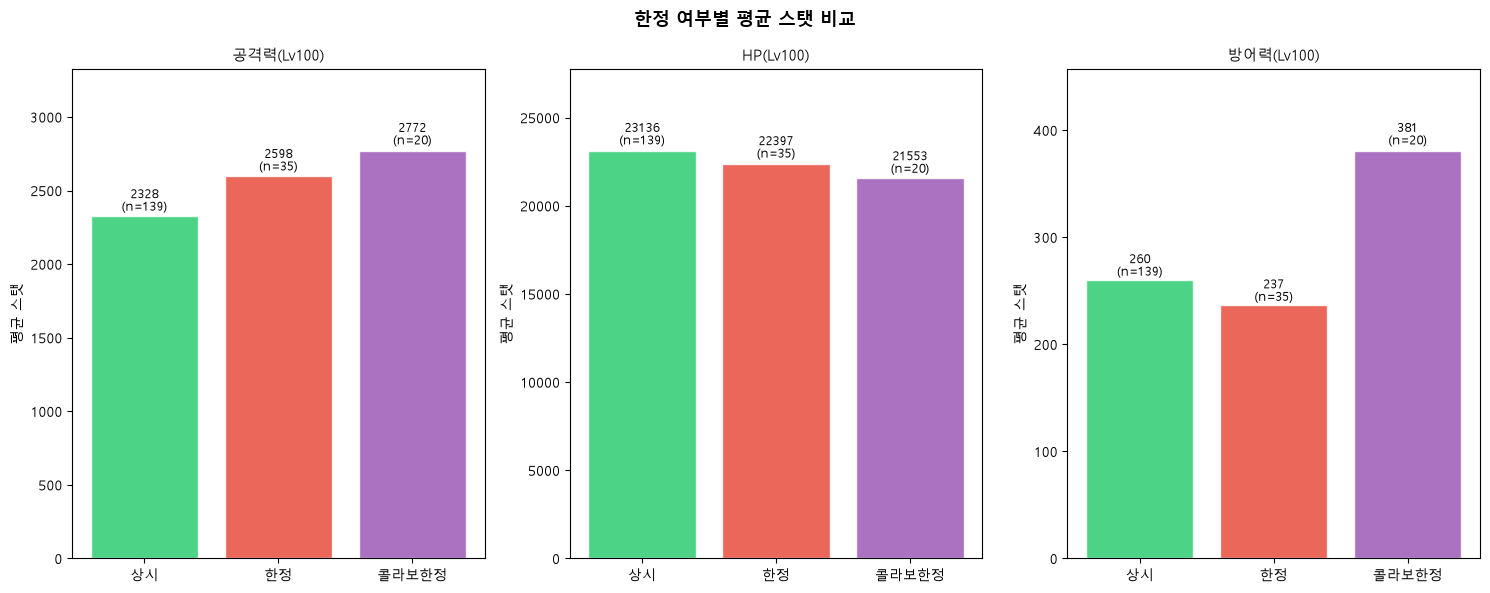

→ reports/eda_limited_stats.png 저장

=== 한정 여부 × 역할 교차표 ===
role_kr        딜러  서포터  차량  탱커  힐러
is_limited_kr                     
상시             71   37   5  13  13
콜라보한정          12    6   1   0   1
한정             24    7   0   3   1


In [10]:
limited_order  = ['상시', '한정', '콜라보한정']
limited_colors = {'상시': '#2ecc71', '한정': '#e74c3c', '콜라보한정': '#9b59b6'}

stat_compare = [('atk_lv100', '공격력(Lv100)'),
                ('hp_lv100',  'HP(Lv100)'),
                ('def_lv100', '방어력(Lv100)')]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, (col, label) in zip(axes, stat_compare):
    group_stats = df.groupby('is_limited_kr')[col].agg(['mean', 'count']).reindex(limited_order)
    colors = [limited_colors[k] for k in group_stats.index]
    bars = ax.bar(group_stats.index, group_stats['mean'],
                  color=colors, alpha=0.85, edgecolor='white')
    for bar, (idx, row) in zip(bars, group_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.015,
                f'{row["mean"]:.0f}\n(n={int(row["count"])})',
                ha='center', fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('평균 스탯')
    ax.set_ylim(0, group_stats['mean'].max() * 1.20)

plt.suptitle('한정 여부별 평균 스탯 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_limited_stats.png', bbox_inches='tight')
plt.show()
print("→ reports/eda_limited_stats.png 저장")

print("\n=== 한정 여부 × 역할 교차표 ===")
print(pd.crosstab(df['is_limited_kr'], df['role_kr']).to_string())

### 한정 여부 해석

한정 학생의 평균 스탯이 상시보다 높게 나온다면, 두 가지 가능성이 있습니다:

1. **진짜 한정 보너스**: 한정 학생이 같은 레어도·역할 내에서도 더 강하게 설계됨 → "과금 유도" 설계의 증거
2. **역할 혼재 효과**: 한정 학생 중 딜러·★3 비중이 높아서 평균이 높아 보이는 것 → 실제 보너스가 아님

**교차표(한정 여부 × 역할)**를 보면 두 그룹의 역할 구성이 다른지 확인할 수 있습니다.

> **Phase 2 예고**: 역할과 레어도를 통제한 상태에서 한정 여부의 독립적 효과를 t-검정으로 검증합니다.

## 9. 지형 적응도 분석

블루아카이브에는 **시가지·야외·실내** 세 종류의 레이드 지형이 있습니다.
적응도가 높은 학생이 해당 지형 레이드에서 더 강합니다.
어떤 지형에 적합한 학생이 많은지, 고적응도(SS·S) 학생의 분포를 파악합니다.

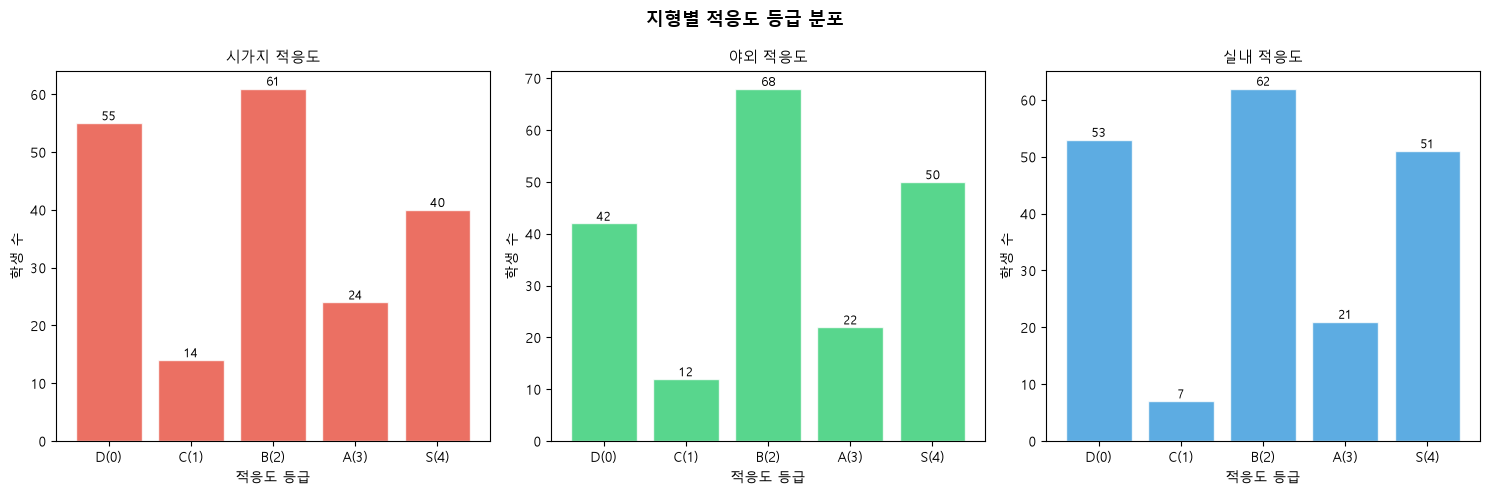

→ reports/eda_terrain.png 저장


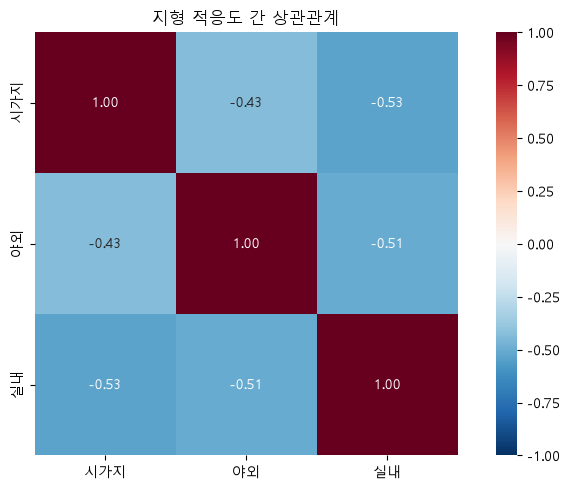


=== 주력 지형(best_terrain) 분포 ===
best_terrain
Street     73
Indoor     61
Outdoor    60

=== 지형 적응도 SS(5) 보유 학생 수 ===
  시가지 적응도 SS: 0명
  야외 적응도 SS: 0명
  실내 적응도 SS: 0명


In [11]:
terrain_info = [
    ('adapt_street',  '시가지 적응도', '#e74c3c'),
    ('adapt_outdoor', '야외 적응도',   '#2ecc71'),
    ('adapt_indoor',  '실내 적응도',   '#3498db'),
]
grade_map = {0: 'D(0)', 1: 'C(1)', 2: 'B(2)', 3: 'A(3)', 4: 'S(4)', 5: 'SS(5)'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label, color) in zip(axes, terrain_info):
    counts = df[col].value_counts().sort_index()
    ax.bar([grade_map.get(k, k) for k in counts.index],
           counts.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('적응도 등급')
    ax.set_ylabel('학생 수')
    for x, y in zip(range(len(counts)), counts.values):
        ax.text(x, y + 0.5, str(y), ha='center', fontsize=9)

plt.suptitle('지형별 적응도 등급 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_terrain.png', bbox_inches='tight')
plt.show()
print("→ reports/eda_terrain.png 저장")

# 지형 적응도 히트맵 (학생별)
fig, ax = plt.subplots(figsize=(8, 5))
terrain_corr = df[['adapt_street', 'adapt_outdoor', 'adapt_indoor']].corr()
sns.heatmap(terrain_corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            xticklabels=['시가지', '야외', '실내'],
            yticklabels=['시가지', '야외', '실내'],
            ax=ax, square=True)
ax.set_title('지형 적응도 간 상관관계')
plt.tight_layout()
plt.show()

print("\n=== 주력 지형(best_terrain) 분포 ===")
print(df['best_terrain'].value_counts().to_string())
print("\n=== 지형 적응도 SS(5) 보유 학생 수 ===")
for col, label, _ in terrain_info:
    n = (df[col] == 5).sum()
    print(f"  {label} SS: {n}명")

### 지형 적응도 해석

- **SS(5점) 학생이 많은 지형**: 그 지형 레이드에서 선택지가 많다는 의미입니다.
  SS 학생이 적은 지형은 특정 학생 의존도가 높아 한정 학생 보유 여부가 메타를 결정합니다.

- **지형 간 상관관계가 음수라면**: 어떤 학생은 특정 지형에 특화되어 있고 다른 지형에는 약합니다.
  반대로 양수라면 "어디서든 강한" 범용 학생이 많다는 뜻입니다.

- **best_terrain 분포**: 어떤 지형에 특화된 학생이 가장 많은지 한눈에 볼 수 있습니다.

> **Phase 3 예고**: 지형 적응도 3개 컬럼을 클러스터링 피처로 포함하면 "지형 특화 유형"이 클러스터로 드러날 것입니다.

## 10. 스탯 간 상관관계 분석

**Spearman 상관계수**를 사용합니다 (Pearson 대신 쓰는 이유: 이상치에 강건하고 비선형 단조 관계도 포착).

- **+1에 가까울수록**: 두 스탯이 함께 높아지는 경향
- **-1에 가까울수록**: 한 스탯이 높으면 다른 스탯이 낮아지는 경향
- **0에 가까울수록**: 두 스탯 간 관련 없음

이 패턴은 **PCA 차원 축소**와 **클러스터링 피처 선택**의 기준이 됩니다.

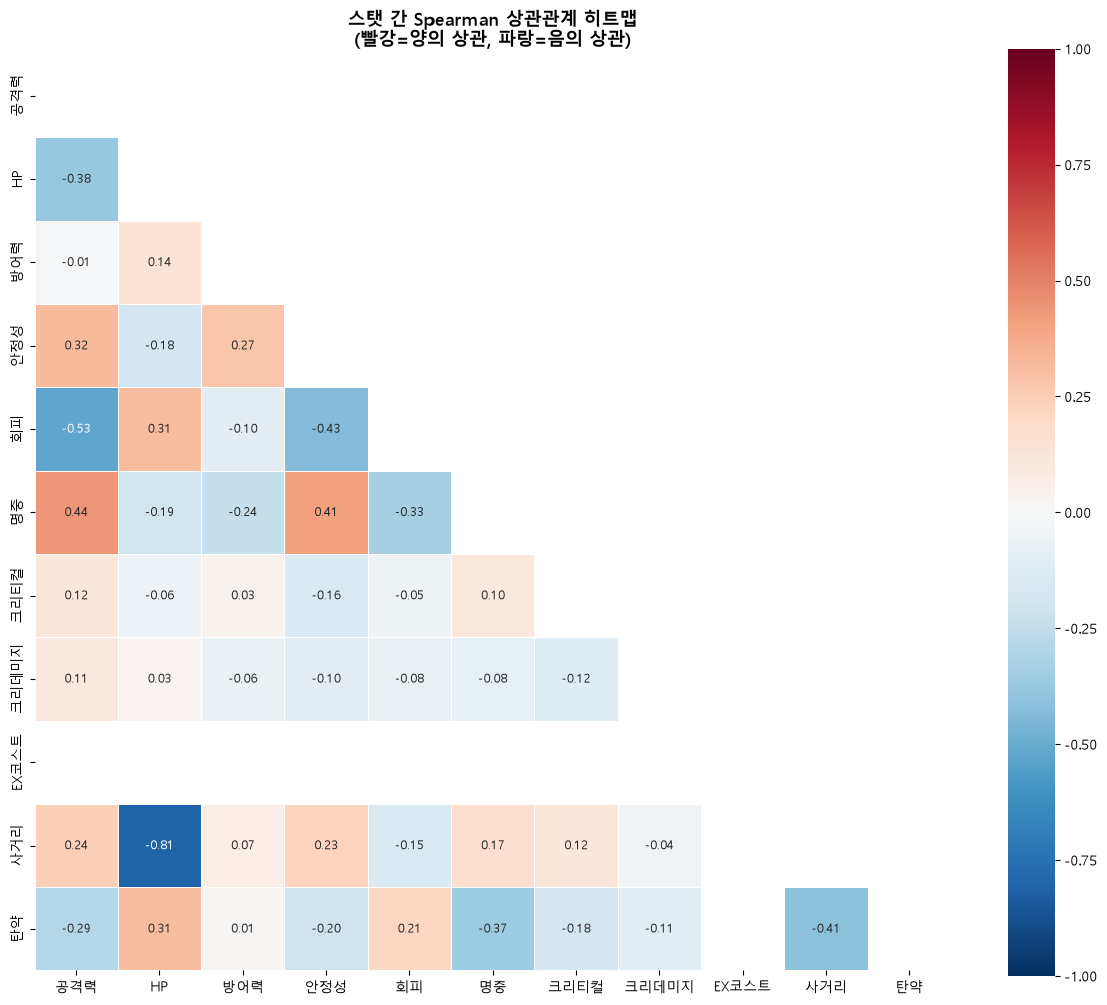

→ reports/eda_correlation.png 저장

=== 주목할 상관관계 쌍 (|r| ≥ 0.4) ===
  HP       ↔ 사거리     : r=-0.809 (음의 상관)
  공격력      ↔ 회피      : r=-0.528 (음의 상관)
  공격력      ↔ 명중      : r=+0.443 (양의 상관)
  안정성      ↔ 회피      : r=-0.434 (음의 상관)
  사거리      ↔ 탄약      : r=-0.412 (음의 상관)
  안정성      ↔ 명중      : r=+0.411 (양의 상관)


In [12]:
corr_cols   = ['atk_lv100', 'hp_lv100', 'def_lv100',
               'stability', 'dodge', 'accuracy',
               'crit_rate', 'crit_dmg_rate', 'ex_cost', 'range', 'ammo_count']
corr_labels = ['공격력', 'HP', '방어력',
               '안정성', '회피', '명중',
               '크리티컬', '크리데미지', 'EX코스트', '사거리', '탄약']

corr_matrix = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 하삼각만 표시
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            xticklabels=corr_labels, yticklabels=corr_labels,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('스탯 간 Spearman 상관관계 히트맵\n(빨강=양의 상관, 파랑=음의 상관)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_correlation.png', bbox_inches='tight')
plt.show()
print("→ reports/eda_correlation.png 저장")

# 강한 상관관계 쌍 출력
print("\n=== 주목할 상관관계 쌍 (|r| ≥ 0.4) ===")
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.4:
            pairs.append((corr_labels[i], corr_labels[j], round(r, 3)))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for c1, c2, r in pairs:
    sign = "양" if r > 0 else "음"
    print(f"  {c1:<8} ↔ {c2:<8}: r={r:+.3f} ({sign}의 상관)")

### 상관관계 해석

**주목할 패턴**:

1. **atk_lv100 ↔ hp_lv100**:
   - 양의 상관이 강하면 → "강한 학생은 모든 스탯이 높다" (레어도 효과가 지배적)
   - 약하거나 음의 상관이면 → 공격형 vs 수비형 설계가 뚜렷

2. **atk_lv100 ↔ crit_rate / crit_dmg_rate**:
   - 공격력이 높은 딜러에게 크리티컬도 높게 설계되면 → 딜러 격차가 복리로 벌어집니다.

3. **def_lv100 ↔ hp_lv100**:
   - 탱커 설계 특성상 양의 상관이 강할 것입니다.

4. **상관이 높은 스탯 쌍**:
   - 클러스터링에서 이 스탯들이 **하나의 주성분(PCA)**으로 묶일 가능성이 높습니다.
   - 상관이 높은 두 스탯을 모두 피처로 넣으면 같은 정보를 중복 반영하게 됩니다.

> **Phase 3 예고**: 상관이 높은 스탯들은 PCA로 압축하거나, 하나만 대표 피처로 선택합니다.

## 11. 추가 필드 탐색 (weapon_type, position)

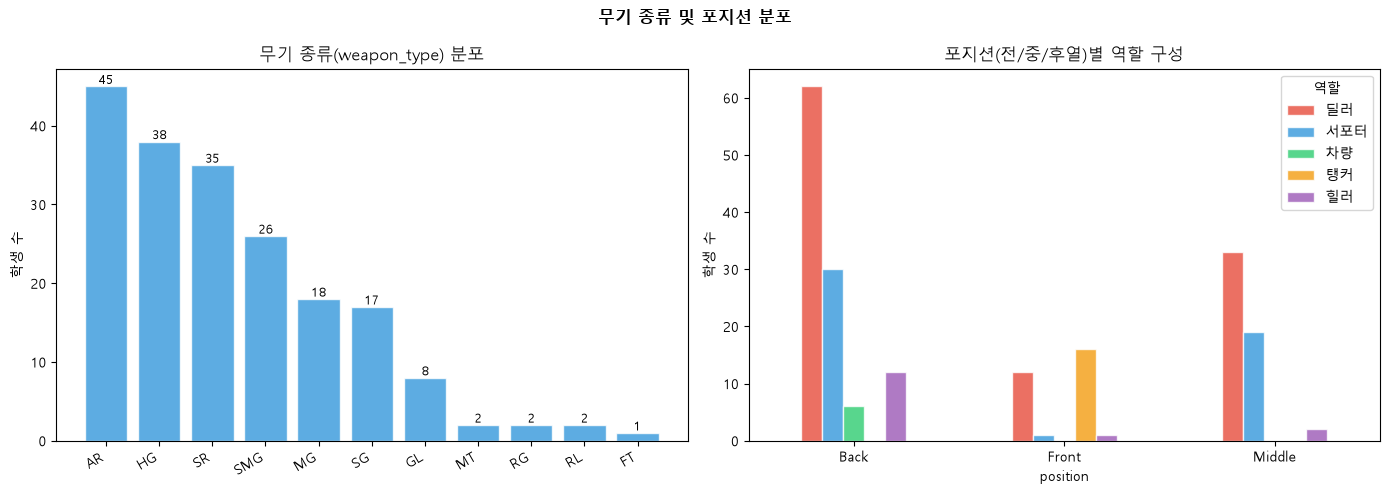

→ reports/eda_weapon_position.png 저장

=== SchaleDB 출시일 정보 없음 확인 ===
released_jp·global·cn 컬럼: True/False 이진값만 제공 (날짜 정보 없음)
글로벌 출시 학생: 172명 / 전체 194명


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# weapon_type
ax = axes[0]
wt_counts = df['weapon_type'].value_counts()
ax.bar(wt_counts.index, wt_counts.values,
       color='#3498db', alpha=0.8, edgecolor='white')
ax.set_title('무기 종류(weapon_type) 분포')
ax.set_ylabel('학생 수')
for x, (k, v) in enumerate(wt_counts.items()):
    ax.text(x, v + 0.3, str(v), ha='center', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# position
ax = axes[1]
pos_data = df.groupby(['position', 'role_kr']).size().unstack(fill_value=0)
pos_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
pos_data.plot(kind='bar', ax=ax,
              color=pos_colors[:len(pos_data.columns)], alpha=0.8, edgecolor='white')
ax.set_title('포지션(전/중/후열)별 역할 구성')
ax.set_ylabel('학생 수')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='역할')

plt.suptitle('무기 종류 및 포지션 분포', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_weapon_position.png', bbox_inches='tight')
plt.show()
print("→ reports/eda_weapon_position.png 저장")

print("\n=== SchaleDB 출시일 정보 없음 확인 ===")
print("released_jp·global·cn 컬럼: True/False 이진값만 제공 (날짜 정보 없음)")
print(f"글로벌 출시 학생: {df['released_global'].sum()}명 / 전체 {len(df)}명")

### 추가 필드 해석

**무기 종류(weapon_type)**:
SR·AR·SMG·MG 등 다양한 무기가 있으며, 사거리(range)·탄약(ammo_count)과 연계됩니다.
"저격형(SR) vs 근거리형(SMG)" 같은 무기 유형도 클러스터링 피처로 추가할 수 있습니다.

**포지션(Front/Middle/Back)**:
전열(Front) 학생이 탱커 역할에 집중되고, 후열(Back) 학생이 딜러·서포터에 집중된다면
포지션이 역할의 강한 대리 변수(proxy)임을 알 수 있습니다.

**SchaleDB 출시일 없음 (재확인)**:
`released_jp/global/cn` 컬럼은 True/False 이진값뿐입니다.
출시 날짜가 필요한 시계열 분석은 나무위키·Fandom 위키 크롤링으로 보완해야 합니다.

## 12. EDA 종합 정리 및 다음 단계 예고

### 핵심 발견 요약

| # | 발견 사항 | 분석적 의미 |
|---|-----------|-------------|
| 1 | **역할별 스탯 구분이 뚜렷** | 딜러↑공격, 탱커↑HP — 클러스터링에서 역할 클러스터 재발견 예상 |
| 2 | **★3가 전체의 80%+** | 레어도별 통계 검정 시 표본 불균형 주의 필요 |
| 3 | **heal_lv100: 힐러/서포터만 유효** | 역할 필터링 없이 heal 분석 시 오해 발생 |
| 4 | **HP 스케일이 공격력·방어력보다 10배+** | 클러스터링 전 StandardScaler 정규화 필수 |
| 5 | **한정 학생 스탯 우위 (육안)** | 역할·레어도 통제 후 통계 검증 필요 |
| 6 | **atk ↔ hp 양의 상관** | "강한 학생은 모든 스탯이 높다" → 레어도 효과로 해석 가능 |
| 7 | **지형 적응도: 특정 지형 편중** | 일부 지형에 SS 학생이 몰려있어 메타 쏠림 가능 |

---

### Phase 2 — 통계 검증 (`02_statistics.ipynb`)

```
[ ] 역할별 공격력 차이: 일원 분산분석(ANOVA) + Tukey HSD post-hoc
[ ] 레어도별 스탯 차이: ANOVA (★1·★2·★3 표본 불균형 고려)
[ ] 한정 vs 상시: 독립 표본 t-검정 (역할·레어도 층화 후 재검정)
[ ] EX코스트 ↔ 공격력: Spearman 상관 + 산점도 (회귀선 포함)
[ ] 전체 스탯 상관의 통계적 유의성 검증
```

### Phase 3 — 클러스터링 (`03_clustering.ipynb`)

```python
# 권장 클러스터링 피처 (EDA 근거)
cluster_features = [
    'atk_lv100', 'hp_lv100', 'def_lv100',        # 핵심 전투 스탯
    'stability', 'crit_rate', 'ex_cost',            # 전투 스타일
    'adapt_street', 'adapt_outdoor', 'adapt_indoor', # 지형 특화
]
# heal_lv100 제외: 결측 많음 (힐러/서포터만 유효)
# 전처리: StandardScaler 정규화 (HP 스케일 문제 해결)
# 최적 K: Elbow + Silhouette Score
```

### Phase 4 — 예측 모델 (`04_prediction.ipynb`)

```python
# ★3 여부 예측 (이진 분류)
target   = (df['star_grade'] == 3).astype(int)
features = cluster_features + ['is_limited', 'bullet_type_enc', 'tactic_role_enc']
# 모델: RandomForestClassifier + LogisticRegression
# 해석: Feature Importance + SHAP
```

---
*노트북 작성일: 2026-06-23 | 데이터: SchaleDB GitHub JSON | 학생 수: 194명 | 컬럼 수: 48*